In [60]:
from astropy.table import Table, vstack, join
import numpy as np
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import os
import pandas as pd

In [61]:
bgs_input_path = "/pscratch/sd/j/jlargett/DESI_SGA_MINE/Morp_Density_Relation/bgs_with_webtype.fits"
bgs_output_path = "/pscratch/sd/j/jlargett/DESI_SGA_MINE/Morp_Density_Relation/bgs_with_webtype_and_vf.fits"

ngc_vflags_path = "/pscratch/sd/j/jlargett/DESI_SGA_MINE/Morp_Density_Relation/NGC_vflags.fits"
sgc_vflags_path = "/pscratch/sd/j/jlargett/DESI_SGA_MINE/Morp_Density_Relation/SGC_vflags.fits"

In [62]:
# Load full BGS
bgs = Table.read(bgs_input_path)

In [63]:
# Ensure persistent full-table row ID
if "ROWID_VF" not in bgs.colnames:
    bgs["ROWID_VF"] = np.arange(len(bgs), dtype=np.int64)

In [64]:
# Rebuild the exact VoidFinder input sample
m_bgs = (bgs["Z"] > 0.02) & (bgs["Z"] < 0.25) & np.isfinite(bgs["Z"])
bgs_vf = bgs[m_bgs].copy()

phot = np.char.strip(np.array(bgs_vf["PHOTSYS"]).astype(str))
ngc_mask = phot == "N"
sgc_mask = phot == "S"

ngc_catalog = Table({
    "ROWID_VF": bgs_vf["ROWID_VF"][ngc_mask],
    "RA": bgs_vf["RA"][ngc_mask],
    "DEC": bgs_vf["DEC"][ngc_mask],
    "Z": bgs_vf["Z"][ngc_mask],
})

sgc_catalog = Table({
    "ROWID_VF": bgs_vf["ROWID_VF"][sgc_mask],
    "RA": bgs_vf["RA"][sgc_mask],
    "DEC": bgs_vf["DEC"][sgc_mask],
    "Z": bgs_vf["Z"][sgc_mask],
})

In [65]:
# Read saved vflag files
ngc_vf = Table.read(ngc_vflags_path)
sgc_vf = Table.read(sgc_vflags_path)

print("NGC columns:", ngc_vf.colnames)
print("SGC columns:", sgc_vf.colnames)

NGC columns: ['gal', 'vflag']
SGC columns: ['gal', 'vflag']


In [66]:
# Initialize full-table vf_flag as unassigned
if "vf_flag" not in bgs.colnames:
    bgs["vf_flag"] = np.full(len(bgs), -1, dtype=np.int16)
else:
    bgs["vf_flag"][:] = -1

In [67]:
# Map NGC back to full BGS rows using gal -> ngc_catalog row -> ROWID_VF
ngc_rowids = np.array(ngc_catalog["ROWID_VF"][ngc_vf["gal"]], dtype=np.int64)
bgs["vf_flag"][ngc_rowids] = np.array(ngc_vf["vflag"], dtype=np.int16)

# Map SGC back to full BGS rows using gal -> sgc_catalog row -> ROWID_VF
sgc_rowids = np.array(sgc_catalog["ROWID_VF"][sgc_vf["gal"]], dtype=np.int64)
bgs["vf_flag"][sgc_rowids] = np.array(sgc_vf["vflag"], dtype=np.int16)

In [68]:
print("Assigned NGC flags:", len(ngc_rowids))
print("Assigned SGC flags:", len(sgc_rowids))
print("Total assigned non--1:", np.sum(bgs["vf_flag"] != -1))

# Save
bgs.write(bgs_output_path, overwrite=True)
print("Wrote:", bgs_output_path)

Assigned NGC flags: 1970058
Assigned SGC flags: 4418273
Total assigned non--1: 6388331
Wrote: /pscratch/sd/j/jlargett/DESI_SGA_MINE/Morp_Density_Relation/bgs_with_webtype_and_vf.fits


In [69]:
# Read merged table
tab = Table.read("/pscratch/sd/j/jlargett/DESI_SGA_MINE/Morp_Density_Relation/bgs_with_webtype_and_vf.fits")

print(tab.colnames)
print("nrows =", len(tab))

# Check unique values
print("Unique vf_flag:", np.unique(tab["vf_flag"]))
print("Unique web_type:", np.unique(tab["web_type"]))

['TARGETID', 'TILEID', 'Z', 'NTILE', 'RA', 'DEC', 'PHOTSYS', 'FRAC_TLOBS_TILES', 'WEIGHT_ZFAIL', 'BITWEIGHTS', 'PROB_OBS', 'WEIGHT', 'WEIGHT_COMP', 'WEIGHT_SYS', 'flux_g_dered', 'flux_r_dered', 'flux_z_dered', 'flux_w1_dered', 'flux_w2_dered', 'web_type', 'ROWID_VF', 'vf_flag']
nrows = 11504552
Unique vf_flag: vf_flag
-------
     -1
      0
      1
      2
      9
Unique web_type:   web_type  
------------
     cluster
    filament
      no_web
outside_cube
outside_mask
        void
        wall


In [99]:
for val in np.unique(tab["web_type"]):
    count = np.sum(tab["web_type"] == val)
    print(val, count)

cluster 824741
filament 3983067
no_web 5116221
outside_cube 144383
outside_mask 2007
void 1254534
wall 179599


In [100]:
for val in np.unique(tab["vf_flag"]):
    count = np.sum(tab["vf_flag"] == val)
    print(val, count)

"""
-1 - Not Classified with MMF (volume limited sample)
0  - Wall
1  - Field
2  - Boundaries
9  - Not in the region VoidFinder was run
"""

-1 5116221
0 1731091
1 852567
2 386428
9 3418245


'\n-1 - Not Classified with MMF (volume limited sample)\n0  - Wall\n1  - Field\n2  - Boundaries\n9  - Not in the region VoidFinder was run\n'

In [101]:
valid_vf = np.isin(tab["vf_flag"], [0, 1])
print(valid_vf.sum())

2583658


In [102]:
web_type = np.array(tab["web_type"], dtype=str)

valid_mmf = np.isin(web_type, ["void", "wall", "filament", "cluster"])
print(valid_mmf.sum())

6241941


In [103]:
valid = valid_vf & valid_mmf
tab_use = tab[valid]

In [104]:
vf_map = {
    0: "Non-Void",
    1: "Void"
}

vf_class = np.array([vf_map[x] for x in tab_use["vf_flag"]])
mmf_class = np.array(tab_use["web_type"]).astype(str)

In [105]:
df = pd.DataFrame({ "vf_class": vf_class, "mmf_class": mmf_class }) 
ct = pd.crosstab(df["vf_class"], df["mmf_class"]) 
ct_norm = pd.crosstab(df["vf_class"], df["mmf_class"], normalize="columns") 
print(ct)
print(ct_norm)

mmf_class  cluster  filament    void   wall
vf_class                                   
Non-Void    275017   1206333  172000  41220
Void         31851    501555  283184  21780
mmf_class   cluster  filament      void      wall
vf_class                                         
Non-Void   0.896206   0.70633  0.377869  0.654286
Void       0.103794   0.29367  0.622131  0.345714


In [106]:
# Binomial errors
N = ct.sum(axis=0)
errors = np.sqrt(ct_norm * (1 - ct_norm) / N)

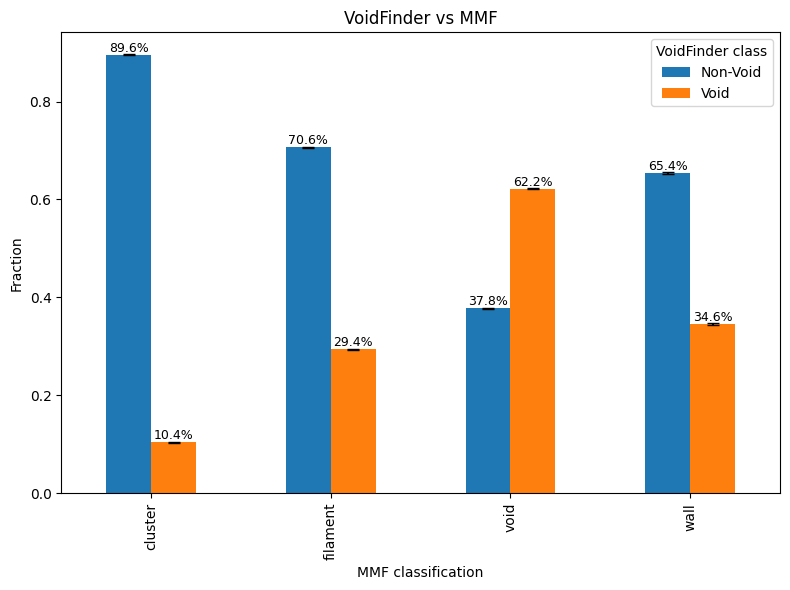

In [107]:
# Plot
ax = ct_norm.T.plot(
    kind="bar",
    yerr=errors.T,
    capsize=4,
    figsize=(8,6)
)

plt.ylabel("Fraction")
plt.xlabel("MMF classification")
plt.title("VoidFinder vs MMF")
plt.legend(title="VoidFinder class")

# Add percentage labels
for container in ax.containers:
    if hasattr(container, "datavalues"):  # only bars
        for bar in container:
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    height,
                    f"{height*100:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

plt.tight_layout()
#plt.savefig("voidfinder_vs_mmf.png", dpi=300, transparent=True)
plt.show()

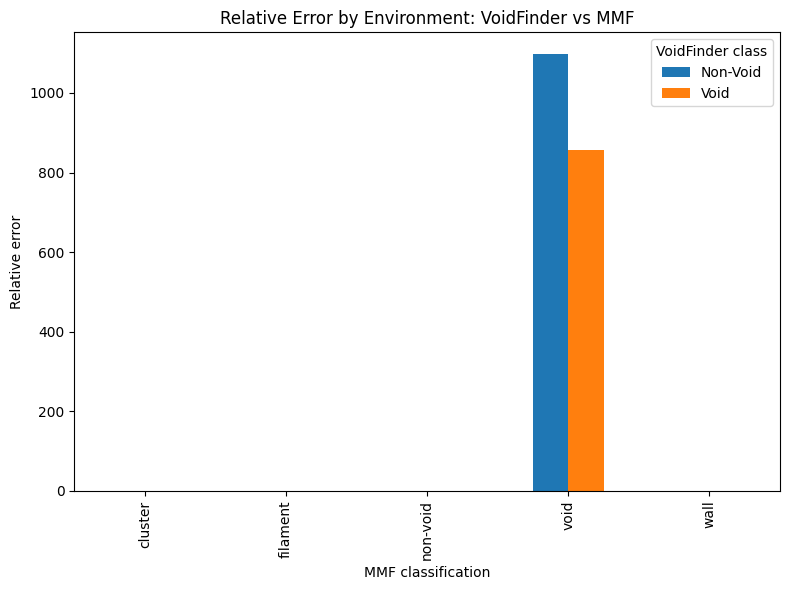

In [97]:
# Relative error
rel_error = errors / ct_norm

# Replace inf/nan where p=0
rel_error = rel_error.replace([np.inf, -np.inf], np.nan)

ax = rel_error.T.plot(kind="bar", figsize=(8,6), capsize=4)

plt.ylabel("Relative error")
plt.xlabel("MMF classification")
plt.title("Relative Error by Environment: VoidFinder vs MMF")
plt.legend(title="VoidFinder class")

plt.tight_layout()
plt.show()

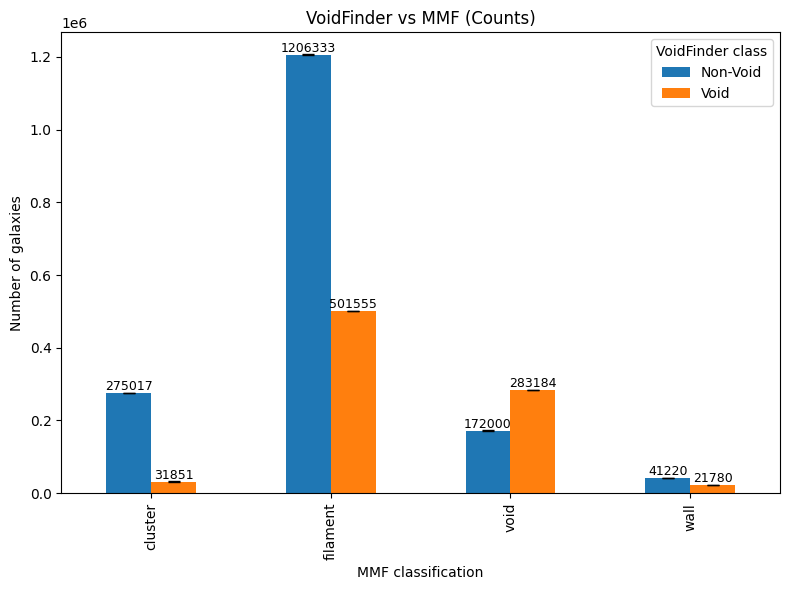

In [90]:
# Poisson errors
errors_counts = np.sqrt(ct)

# Plot counts
ax = ct.T.plot(
    kind="bar",
    yerr=errors_counts.T,
    capsize=4,
    figsize=(8,6)
)

plt.ylabel("Number of galaxies")
plt.xlabel("MMF classification")
plt.title("VoidFinder vs MMF (Counts)")
plt.legend(title="VoidFinder class")

# Add count labels
for container in ax.containers:
    if hasattr(container, "datavalues"):  # only bars
        for bar in container:
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    height,
                    f"{int(height)}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

plt.tight_layout()
plt.show()

In [91]:
df["mmf_binary"] = np.where(df["mmf_class"] == "void", "void", "non-void")

In [92]:
ct_bin = pd.crosstab(df["vf_class"], df["mmf_binary"])
print(ct_bin)

mmf_binary  non-void    void
vf_class                    
Non-Void     1522570  172000
Void          555186  283184


In [93]:
ct_bin_col = pd.crosstab(df["vf_class"], df["mmf_binary"], normalize="columns")
print(ct_bin_col)

mmf_binary  non-void      void
vf_class                      
Non-Void    0.732795  0.377869
Void        0.267205  0.622131


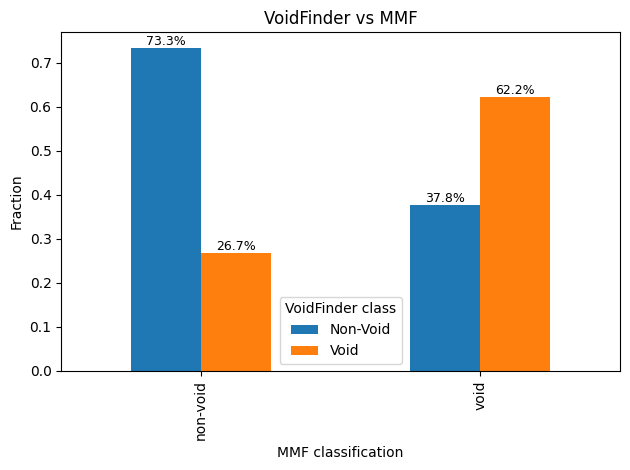

In [94]:
ax = ct_bin_col.T.plot(kind="bar")

plt.ylabel("Fraction")
plt.xlabel("MMF classification")
plt.title("VoidFinder vs MMF")
plt.legend(title="VoidFinder class")

# Add percentage labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # avoid labeling empty bars
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height*100:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.tight_layout()
plt.show()

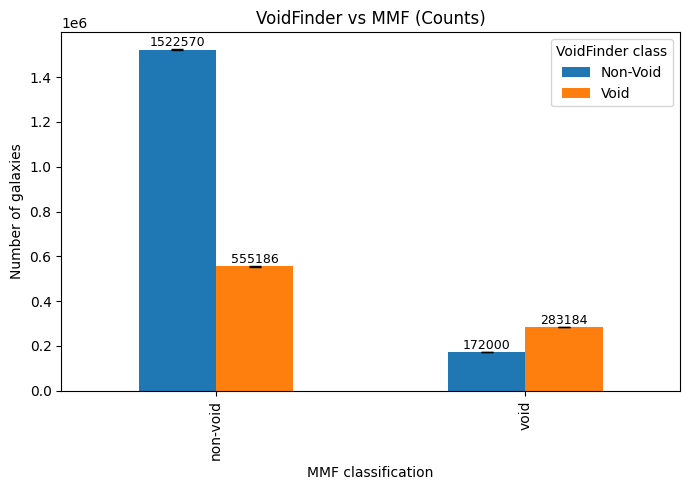

In [95]:
# Raw counts
ct = pd.crosstab(df["vf_class"], df["mmf_binary"])

# Poisson errors
errors = np.sqrt(ct)

# Plot
ax = ct.T.plot(
    kind="bar",
    yerr=errors.T,
    capsize=4,
    figsize=(7,5)
)

plt.ylabel("Number of galaxies")
plt.xlabel("MMF classification")
plt.title("VoidFinder vs MMF (Counts)")
plt.legend(title="VoidFinder class")

# add count labels
for container in ax.containers:
    if not hasattr(container, "datavalues"):
        continue

    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + np.sqrt(height),  # place above error bar
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.tight_layout()
plt.show()